In [1]:

# oktibbeha county fips code: 105
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask
from shapely.geometry import Polygon
import numpy as np
from rasterio.transform import xy
from shapely.geometry import Point
from src.mslandcover.config import LEGEND_CLASSES

ms_places = gpd.read_file('./data/shapefiles/tl_2024_28_place')

okt_confidence_raster_path = r"Z:\guser\dh\MS_HiRes_LC_Prelim\105\lc_confidence_clipped.tif"
with rio.open(okt_confidence_raster_path) as src:
    okt_confidence_profile = src.profile

places_of_interest = ms_places.loc[ms_places['NAME'].isin(['Starkville', 'Mississippi State'])].to_crs(okt_confidence_profile['crs'])

places_of_interest = places_of_interest.dissolve()
geom = Polygon(places_of_interest['geometry'].iloc[0].exterior.coords)

with rio.open(okt_confidence_raster_path) as src:
    lc_confidence, out_transform = mask(src, [geom], crop=True, all_touched=True)
    out_profile = src.profile
    out_profile.update(
        height=lc_confidence.shape[1],
        width=lc_confidence.shape[2],
        transform=out_transform
    )
    
with rio.open(r"G:\postprocessing_tests\okt_confidence_clipped.tif", 'w', **out_profile) as dst:
    dst.write(lc_confidence)

okt_classes_raster_path = okt_confidence_raster_path.replace('confidence', 'classes')
with rio.open(okt_classes_raster_path) as src:
    lc_classes, out_transform = mask(src, [geom], crop=True, all_touched=True)
    out_profile = src.profile
    out_profile.update(
        height=lc_classes.shape[1],
        width=lc_classes.shape[2],
        transform=out_transform
    )
    cmap = src.colormap(1)

with rio.open(r"G:\postprocessing_tests\okt_classes_clipped.tif", 'w', **out_profile) as dst:
    dst.write(lc_classes)
    dst.write_colormap(1, cmap)

okt_probs_raster_path = okt_confidence_raster_path.replace('confidence', 'probs')
with rio.open(okt_probs_raster_path) as src:
    lc_probs, out_transform = mask(src, [geom], crop=True, all_touched=True)
    out_profile = src.profile
    out_profile.update(
        height=lc_probs.shape[1],
        width=lc_probs.shape[2],
        transform=out_transform
    )

with rio.open(r"G:\postprocessing_tests\okt_probs_clipped.tif", 'w', **out_profile) as dst:
    dst.write(lc_probs)

okt_imagery_raster_path = r"G:\NAIP_MS_2023\ortho_1-1_hc_s_ms105_2023_1\ortho_1-1_hc_s_ms105_2023_1_1m.tif"
with rio.open(okt_imagery_raster_path) as src:
    okt_imagery, out_transform = mask(src, [geom], crop=True, all_touched=True)
    out_profile = src.profile
    out_profile.update(
        height=okt_imagery.shape[1],
        width=okt_imagery.shape[2],
        transform=out_transform
    )

with rio.open(r"G:\postprocessing_tests\okt_imagery_clipped.tif", 'w', **out_profile) as dst:
    dst.write(okt_imagery)


lc_confidence = lc_confidence.squeeze()
lc_classes = lc_classes.squeeze()
lc_probs = lc_probs.squeeze()
okt_imagery = okt_imagery.transpose(1, 2, 0)

In [9]:
# randomly sample points where confidence is low
np.random.seed(1701)

n_samples = 200
max_confidence = 25

# randomly sample points where confidence is below threshold and class is not 0
pop_points = np.argwhere((lc_confidence < max_confidence) & (lc_classes != 0))
sample_indices = np.random.choice(range(pop_points.shape[0]), n_samples, replace=False)
sample_points = pop_points[sample_indices]

# get predicted classes for each sample point
sample_classes = lc_classes[sample_points[:, 0], sample_points[:, 1]]
sample_class_names = [LEGEND_CLASSES[cls] for cls in sample_classes]

# convert sample points to coordinates in raster crs
sample_coords = [Point(xy(out_transform, point[0], point[1])) for point in sample_points]


sampled_points_gdf = gpd.GeoDataFrame({
    'confidence': lc_confidence[sample_points[:, 0], sample_points[:, 1]],
    'pred_class_index': sample_classes,
    'pred_class_name': sample_class_names,
},geometry=sample_coords, crs=places_of_interest.crs)
sampled_points_gdf.to_file(r"G:\postprocessing_tests\sampled_points.gpkg")

In [ ]:
from skimage.segmentation import quickshift
from rasterio.features import shapes
from sklearn.metrics import f1_score
import multiprocessing as mp
from rasterio.features import geometry_mask, shapes
from shapely.geometry import shape
from tqdm import tqdm

sampled_points_annotated_gdf = gpd.read_file('./data/shapefiles/okt_ms_low_confidence_point_samples.gpkg')

# param_grid = {
    
# }

def process_chunk(image_chunk, seg_func, seg_params):
    """
    Processes a single chunk of the image using the segmentation function.
    """
    # Apply segmentation function to the chunk
    return seg_func(image_chunk, **seg_params)

def parallel_segment(image, seg_func, seg_params, chunk_size=1024, n_procs=16):
    """
    Segment the image using a parallelized approach with chunking.

    Args:
    - image: Input image to segment.
    - seg_func: Segmentation function (e.g., skimage.segmentation.slic).
    - seg_params: Parameters for the segmentation function.
    - chunk_size: Size of each chunk.
    - n_procs: Number of processes for parallel execution.

    Returns:
    - segmented_image: The segmented image.
    """
    # Get image dimensions
    img_height, img_width = image.shape[:2]
    segmented_image = np.zeros((img_height, img_width), dtype=np.int32)

    # Generate list of chunks with no overlap (stride removed)
    chunks = []
    for i in range(0, img_height, chunk_size):
        for j in range(0, img_width, chunk_size):
            chunks.append((i, j))

    # Apply segmentation to chunks in parallel
    with mp.Pool(n_procs) as pool:
        # Process each chunk in parallel
        results = []
        # Use a tqdm progress bar that updates once per chunk processed
        for i, j in chunks:
            # Extract the chunk from the image
            chunk = image[i:i + chunk_size, j:j + chunk_size]
            # Apply segmentation to the chunk
            result = pool.apply_async(process_chunk, (chunk, seg_func, seg_params))
            results.append((i, j, result))

        # Create a tqdm progress bar that updates based on the number of results processed
        with tqdm(total=len(chunks), desc="Processing chunks", unit='chunk') as pbar:
            for i, j, result in results:
                chunk_seg = result.get()  # Get the result from the async process
                segmented_image[i:i + chunk_size, j:j + chunk_size] = chunk_seg
                pbar.update(1)  # Update progress bar for each chunk processed

    return segmented_image

def process_segment(segment):
    segment_mask = segmented_image == segment
    segment_probs = lc_probs[:, segment_mask]
    mean_probs = np.mean(segment_probs, axis=1)
    return segment, mean_probs

segment_fn = quickshift
params = {
    'ratio': 0.5,
    'kernel_size': 3,
    'max_dist': 5,
}
print(f'Running segmentation with {segment_fn.__name__} and params: {params}')
segmented_image = parallel_segment(okt_imagery, segment_fn, params, chunk_size=512, n_procs=mp.cpu_count())
print(f'Segmentation complete.')
unique_segments = np.unique(segmented_image)
print(f'Found {len(unique_segments)} unique segments.')

postprocessed_probabilities = np.zeros_like(lc_probs)
postprocessed_classes = np.zeros_like(lc_classes)

with mp.Pool(mp.cpu_count()) as pool:
    results = pool.imap_unordered(process_segment, unique_segments, chunksize=256)
print(f'Submitted all segments for processing.')

for segment, mean_probs in tqdm(results, desc='Processing segments', total=len(unique_segments), unit='segment'):
    segment_mask = segmented_image == segment
    postprocessed_probabilities[:, segment_mask] = mean_probs[:, np.newaxis]
    postprocessed_classes[segment_mask] = np.argmax(mean_probs) + 1

bounding_mask = geometry_mask([geom], out_shape=lc_classes.shape, transform=out_transform, invert=False, all_touched=True)
vector_classes = list(shapes(postprocessed_classes, bounding_mask, transform=out_transform))
class_pred_idx = [int(val) for _, val in vector_classes]
geoms = [shape(geom) for geom, _ in vector_classes]
segmented_gdf = gpd.GeoDataFrame({
    'new_pred_class_index': class_pred_idx,
}, geometry=geoms, crs=places_of_interest.crs)

# now, join the segmented gdf with the ground truth data
segmented_gdf['new_pred_class_name'] = segmented_gdf['new_pred_class_index'].apply(lambda x: LEGEND_CLASSES[x])
data_joined_gdf = gpd.sjoin(sampled_points_annotated_gdf, segmented_gdf, how='left')
data_joined_gdf

metric = f1_score(data_joined_gdf['true_class_index'], data_joined_gdf['new_pred_class_index'], average='macro')

Running segmentation with quickshift and params: {'ratio': 0.5, 'kernel_size': 3, 'max_dist': 5}


Processing chunks:   0%|          | 0/550 [00:00<?, ?it/s]

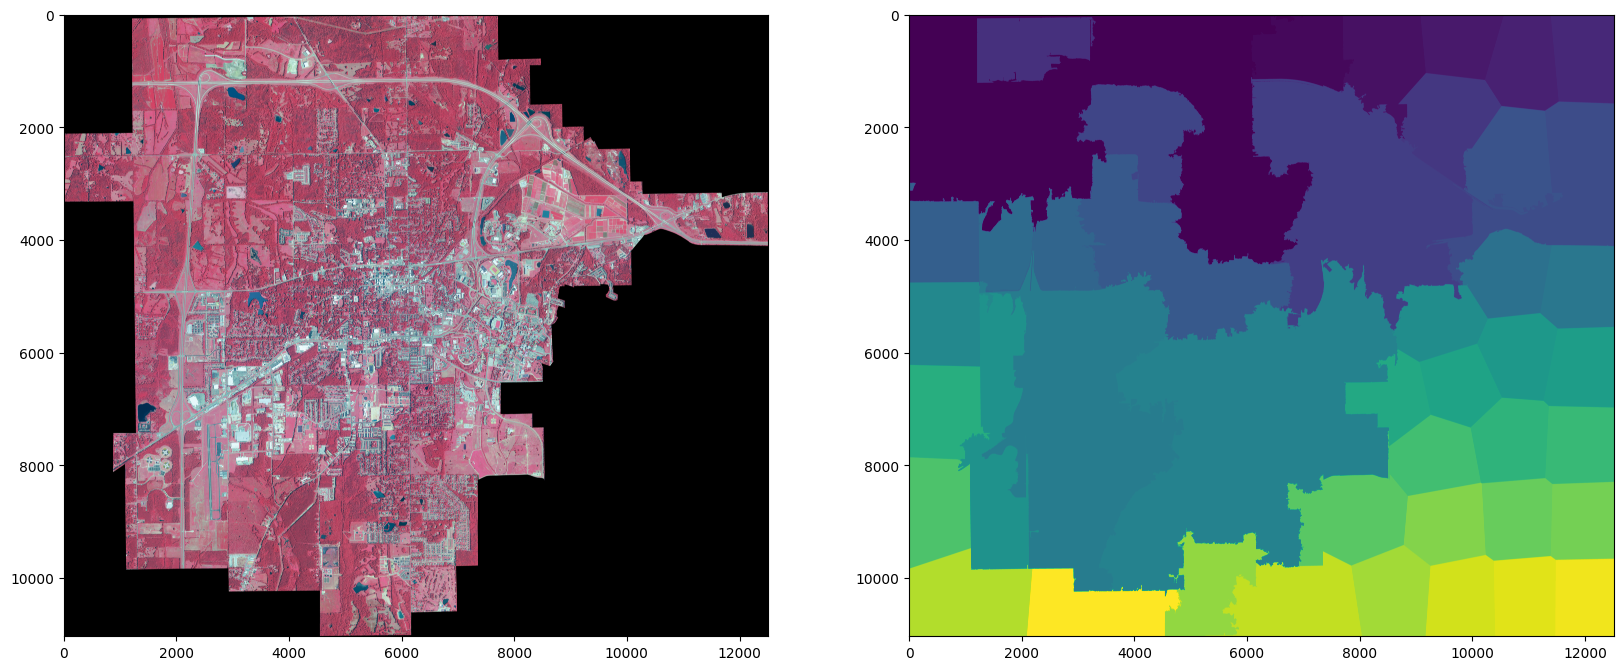

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(okt_imagery)
ax[1].imshow(segmented_image)
